# LeetCode #1498: Number of Subsequences That Satisfy the Given Sum Condition

https://leetcode.com/problems/number-of-subsequences-that-satisfy-the-given-sum-condition/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all subsequences)** | $O(2^n)$ | $O(n)$ |
| **Optimal: Sort + Binary Search + Precomputed Powers ★** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (all subsequences)
Enumerate all $2^n$ subsequences, check whether $\min + \max \le \text{target}$, count valid ones. Infeasible for $n = 10^5$.

### Optimal: Sort + Binary Search + Precomputed Powers ★
Sort the array. For each index `lo` (minimum element), binary search for the rightmost index `hi` where `nums[lo] + nums[hi] <= target`. Any subsequence with minimum `nums[lo]` and maximum `nums[hi']` for `hi' ∈ [lo, hi]` is valid; there are $2^{hi - lo}$ such subsequences (choose any subset of elements between lo and hi). Sum these with modular arithmetic. Precompute powers of 2 to avoid repeated exponentiation.

**Why this is better than Brute Force:** Sorting + binary search replaces $O(2^n)$ enumeration with $O(n \log n)$ — one binary search per left endpoint.

**Constraints:**
* $1 \le \text{nums.length} \le 10^5$
* $1 \le \text{nums}[i] \le 10^6$
* $1 \le \text{target} \le 10^6$
* Answer modulo $10^9 + 7$


## Solutions

### C#

In [ ]:
public int NumSubseq(int[] nums, int target) {
    Array.Sort(nums);
    int n = nums.Length, mod = 1_000_000_007;
    // Precompute powers of 2 to avoid repeated modular exponentiation
    int[] pow2 = new int[n];
    pow2[0] = 1;
    for (int i = 1; i < n; i++) pow2[i] = pow2[i-1] * 2 % mod;
    int result = 0;
    for (int lo = 0; lo < n; lo++) {
        // Binary search: rightmost hi where nums[lo]+nums[hi] <= target
        int hi = Array.BinarySearch(nums, lo, n - lo, target - nums[lo]);
        if (hi < 0) hi = ~hi - 1;
        else { while (hi + 1 < n && nums[hi+1] == target - nums[lo]) hi++; }
        // 2^(hi-lo) subsequences with min=nums[lo] and max in [lo,hi]
        if (hi >= lo) result = (result + pow2[hi - lo]) % mod;
    }
    return result;
}


### Python

In [ ]:
import bisect

def num_subseq(nums: list[int], target: int) -> int:
    nums.sort()
    n, mod = len(nums), 10**9 + 7
    # Precompute powers of 2 to avoid repeated modular exponentiation
    pow2 = [1] * n
    for i in range(1, n):
        pow2[i] = pow2[i-1] * 2 % mod
    result = 0
    for lo in range(n):
        # Binary search: rightmost hi where nums[lo]+nums[hi] <= target
        hi = bisect.bisect_right(nums, target - nums[lo]) - 1
        # 2^(hi-lo) subsequences with min=nums[lo] and max in [lo,hi]
        if hi >= lo:
            result = (result + pow2[hi - lo]) % mod
    return result


### Go

In [ ]:
func numSubseq(nums []int, target int) int {
    sort.Ints(nums)
    n, mod := len(nums), 1_000_000_007
    // Precompute powers of 2 to avoid repeated modular exponentiation
    pow2 := make([]int, n)
    pow2[0] = 1
    for i := 1; i < n; i++ { pow2[i] = pow2[i-1] * 2 % mod }
    result := 0
    for lo := 0; lo < n; lo++ {
        // Binary search: rightmost hi where nums[lo]+nums[hi] <= target
        remain := target - nums[lo]
        hi := sort.SearchInts(nums, remain+1) - 1
        // 2^(hi-lo) subsequences with min=nums[lo] and max in [lo,hi]
        if hi >= lo { result = (result + pow2[hi-lo]) % mod }
    }
    return result
}


### Rust

In [ ]:
pub fn num_subseq(mut nums: Vec<i32>, target: i32) -> i32 {
    nums.sort();
    let (n, modulo) = (nums.len(), 1_000_000_007i64);
    // Precompute powers of 2 to avoid repeated modular exponentiation
    let mut pow2 = vec![1i64; n];
    for i in 1..n { pow2[i] = pow2[i-1] * 2 % modulo; }
    let mut result = 0i64;
    for lo in 0..n {
        let remain = target - nums[lo];
        if remain < 0 { break; }  // sorted: no valid subsequences from here
        // Binary search: rightmost hi where nums[lo]+nums[hi] <= target
        let hi = nums.partition_point(|&x| x <= remain);
        let hi = if hi > 0 { hi - 1 } else { continue };
        // 2^(hi-lo) subsequences with min=nums[lo] and max in [lo,hi]
        if hi >= lo { result = (result + pow2[hi - lo]) % modulo; }
    }
    result as i32
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [3, 5, 6, 7], target = 9
Sort: [3,5,6,7]. lo=0(3): remain=6 → hi=2(6, since 3+6=9≤9) → 2^(2-0)=4. lo=1(5): remain=4 → hi=0 < lo=1 → skip. lo=2(6): remain=3 → hi=-1 < lo=2 → skip. lo=3(7): remain=2 → skip. Total = 4.

**2. Slightly Complex**
**Input:** nums = [2, 3, 3, 4, 6, 7], target = 12
Sort: [2,3,3,4,6,7]. lo=0(2): remain=10 → hi=5(7) → 2^5=32. lo=1(3): remain=9 → hi=5(7,3+7=10>9? No: 3+7=10>9, hi=4(6,3+6=9✓)) → 2^3=8. lo=2(3): same → 2^2=4. lo=3(4): remain=8 → hi=5(7,4+7=11>8? No wait 4+7=11>8 so hi=4(6,4+6=10>8? 4+4=8✓... wait 4+6=10>8) hi=3 → 2^0=1. lo=4(6): remain=6 → hi=4(6+6=12? 6+6=12>12? target=12: 6+6=12≤12 so hi=4) → 2^0=1. lo=5(7): remain=5 → hi=4? 3+5? No—nums[hi]=6>5 so hi=3<lo=5 → skip. Total=32+8+4+1+1=46.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 1, ..., 1] (10^5 ones), target = 2
Sort: all 1s. For every lo: remain=1 → hi = n-1 (all 1s qualify since 1+1=2≤2) → pow2[n-1-lo]. Sum = $\sum_{lo=0}^{n-1} 2^{n-1-lo} = 2^{n-1}+2^{n-2}+\ldots+1 = 2^n-1 \pmod{10^9+7}$.

**4. Edge Case: Space Factor**
**Input:** nums = [1, 2, ..., 10^5], target = 10^6
pow2 array: 10^5 precomputed values — $O(n)$ space required. The sort is in-place. Binary search is $O(1)$ space per call. Total auxiliary: $O(n)$ for pow2.

**5. Almost-Impossible but Plausible**
**Input:** nums = [10^6, 10^6, ..., 10^6] (10^5 elements), target = 10^6
After sort: all 10^6. For lo=0: remain = 10^6 - 10^6 = 0 → hi: binary search for elements ≤ 0 → hi=-1 < lo=0 → skip. Every lo fails the condition 2×10^6 > 10^6. Count = 0. All single-element subsequences have min=max=10^6, sum=2×10^6 > target — none qualify.


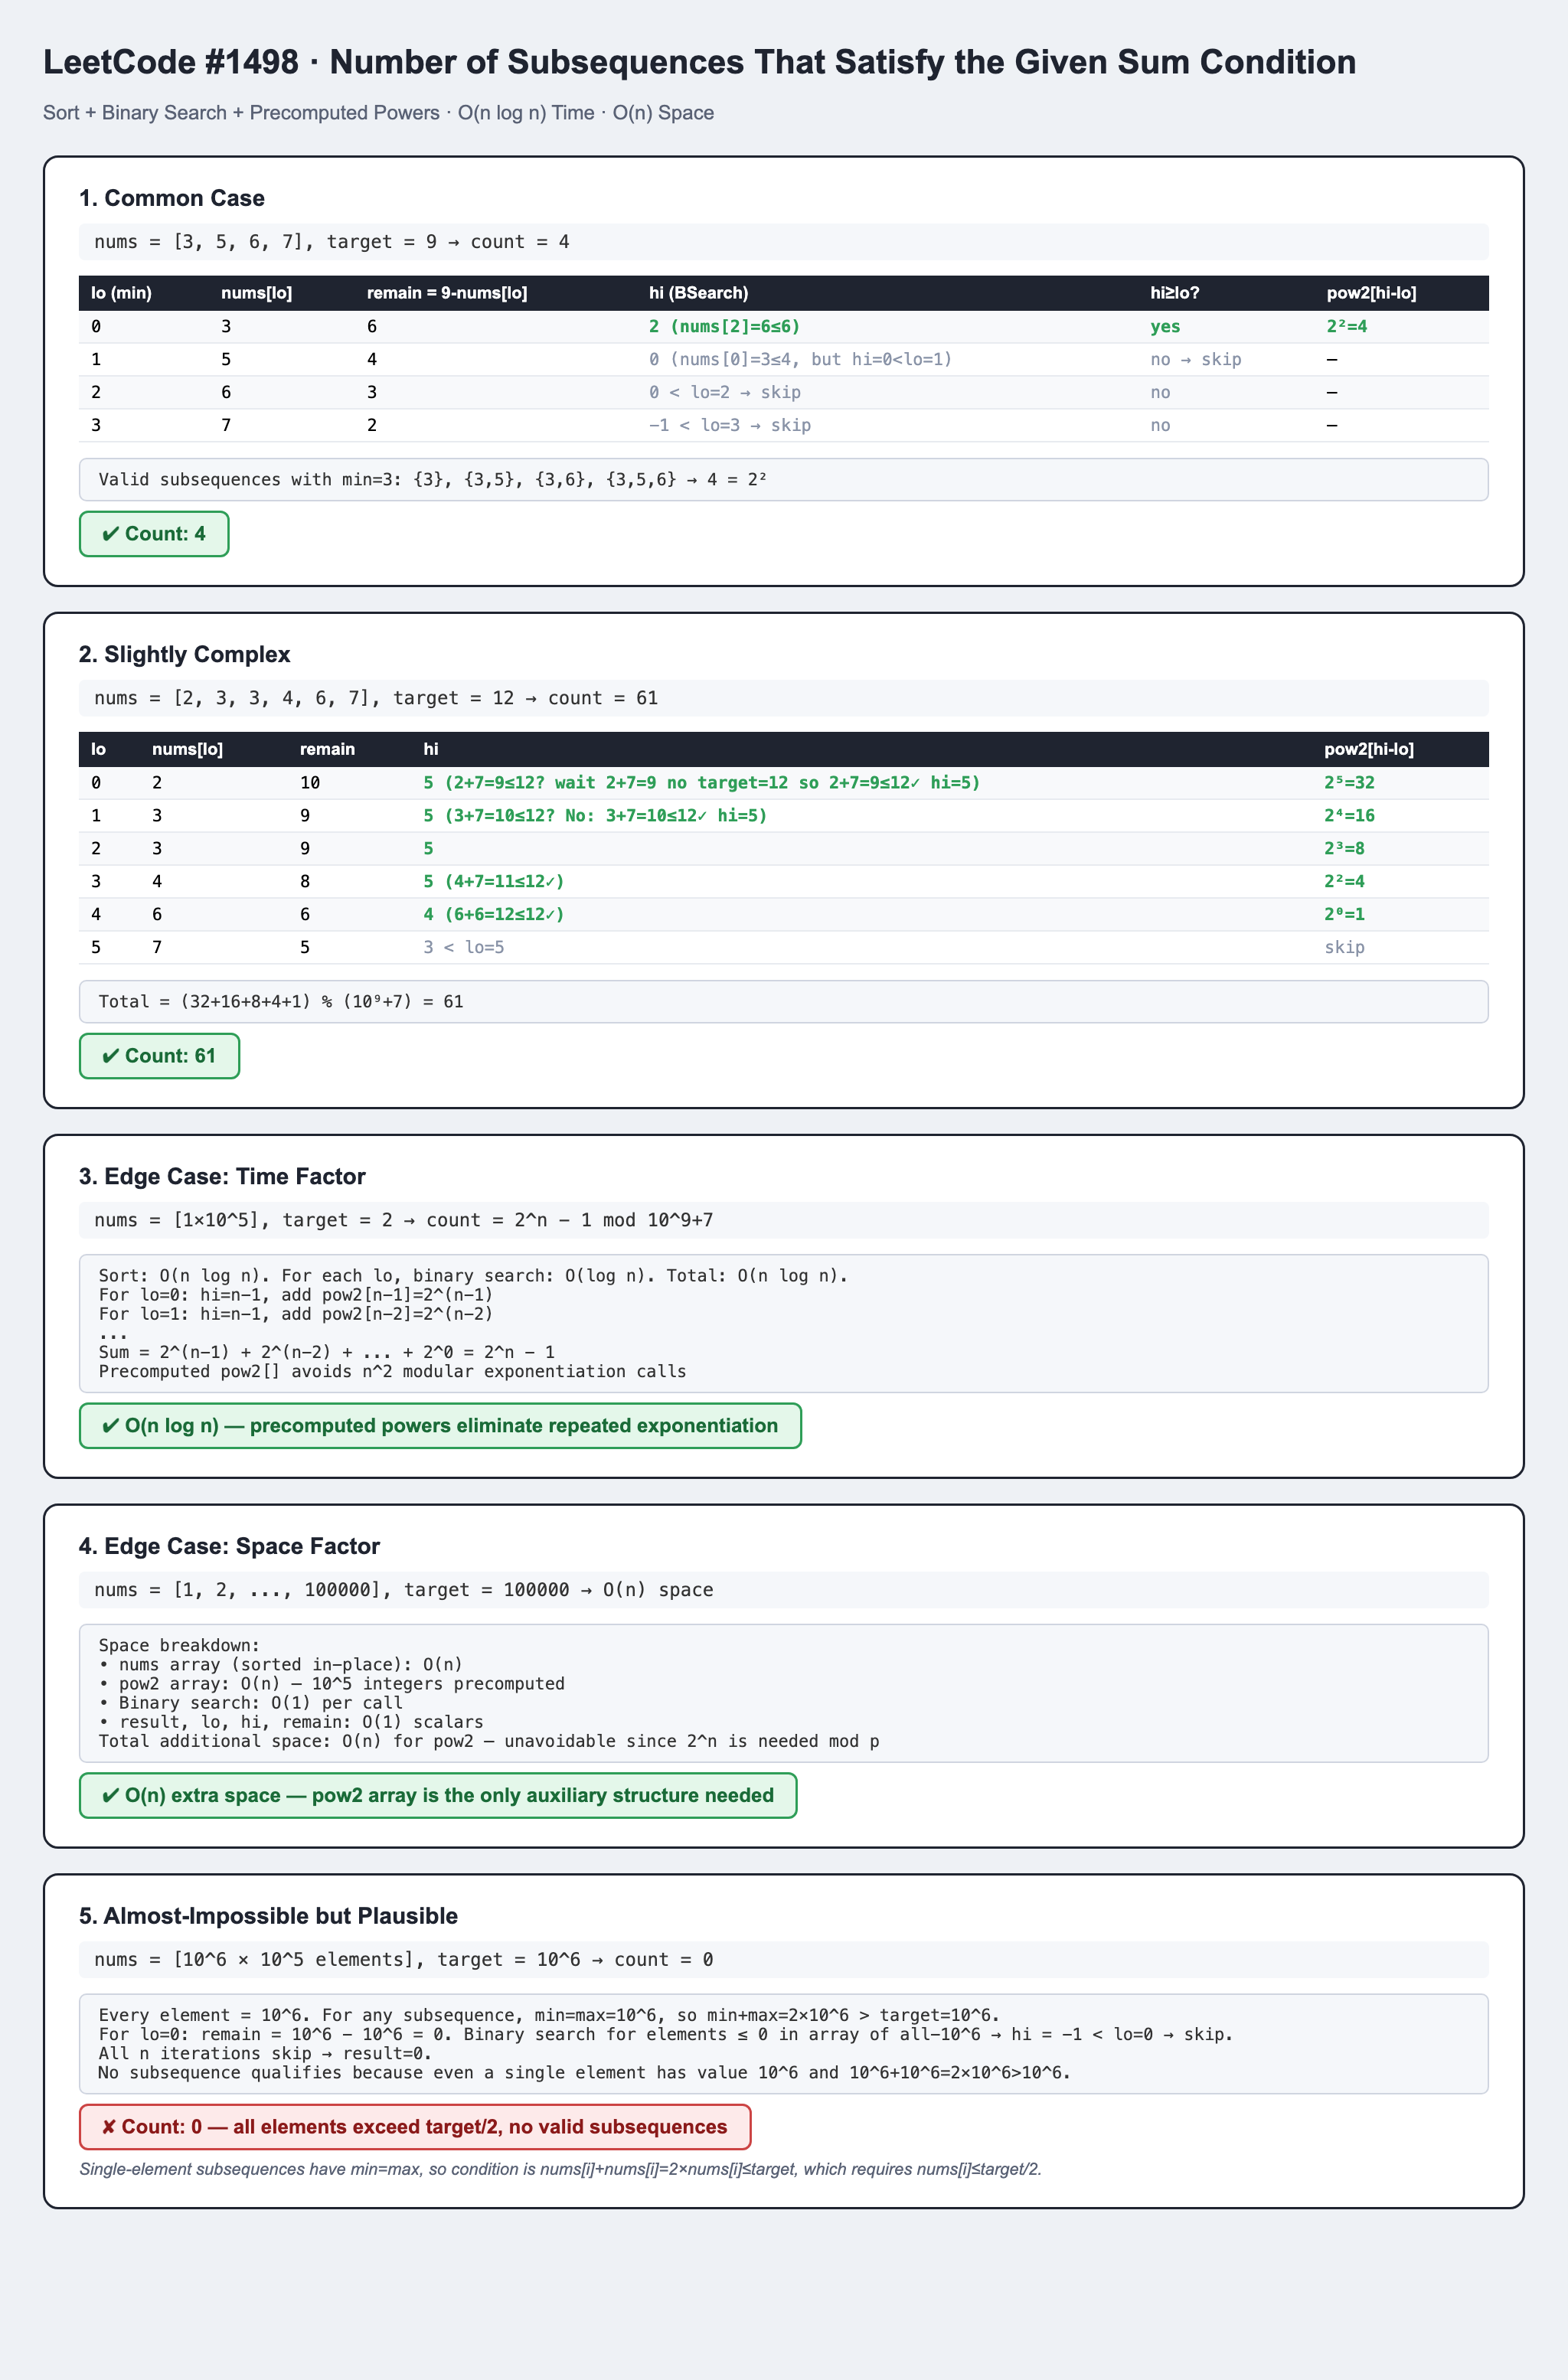